# Multi-Horizon Target Study

Test whether AlphaLens features carry more stable excess-return signal over 5, 10, 20, 30, or 60 trading sessions. Model configurations and four pre-July-2025 walk-forward folds are fixed before comparing horizons. Exploring several targets can nominate a future-holdout candidate, but cannot create a production champion.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.target_study import (
    build_horizon_feature_datasets,
    run_target_study,
    target_study_to_json,
)

In [2]:
datasets = build_horizon_feature_datasets()
study = run_target_study(datasets)
payload = target_study_to_json(study)

print(f'Horizons: {list(study.benchmarks)}')
print(f'Model candidates per horizon: {len(next(iter(study.benchmarks.values())).candidates)}')
print(f'Walk-forward folds: {len(next(iter(study.benchmarks.values())).folds)}')

Horizons: [5, 10, 20, 30, 60]
Model candidates per horizon: 7
Walk-forward folds: 4


## Horizon Comparison

A horizon is eligible only when its best learned model beats historical-mean MAE, wins a strict majority of folds, and retains positive pooled rank correlation.

In [3]:
study.horizon_summary.style.format({
    'model_mean_mae': '{:.4f}',
    'historical_mean_mae': '{:.4f}',
    'absolute_mae_improvement': '{:+.5f}',
    'relative_mae_improvement': '{:+.2%}',
    'pooled_spearman_ic': '{:.3f}',
})

,horizon,target,labeled_oof_rows,selected_model,selected_family,model_mean_mae,historical_mean_mae,absolute_mae_improvement,relative_mae_improvement,fold_wins,fold_count,pooled_spearman_ic,eligible_for_fresh_holdout
0,5,excess_return_5d,317,xgboost_registered_shape,xgboost,0.0251,0.0255,+0.00044,+1.73%,2,4,0.211,False
1,10,excess_return_10d,314,elasticnet_a01_l50,elasticnet,0.0343,0.0347,+0.00041,+1.17%,3,4,0.162,True
2,20,excess_return_20d,306,elasticnet_a01_l50,elasticnet,0.0504,0.0505,+0.00014,+0.28%,2,4,0.198,False
3,30,excess_return_30d,294,xgboost_registered_shape,xgboost,0.0652,0.0650,-0.00023,-0.35%,2,4,0.082,False
4,60,excess_return_60d,158,extra_trees_depth4,extra_trees,0.0800,0.0768,-0.00320,-4.17%,1,4,-0.123,False


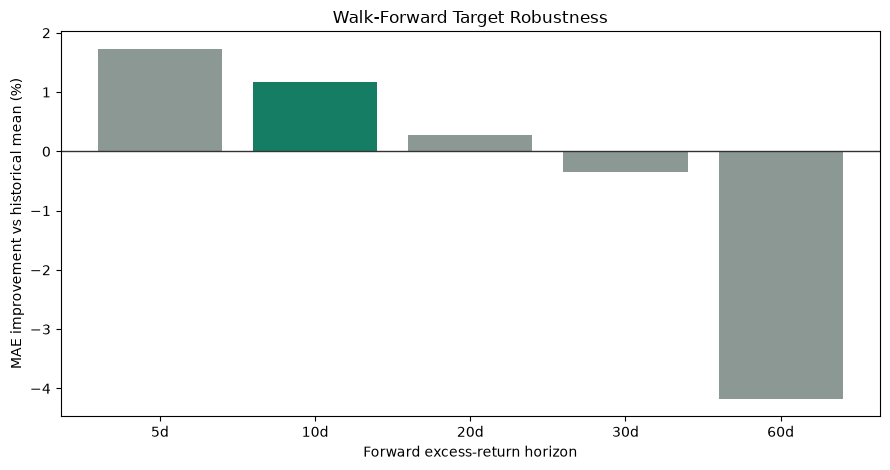

In [4]:
plot_frame = study.horizon_summary.copy()
colors = [
    '#147d64' if eligible else '#8c9893'
    for eligible in plot_frame.eligible_for_fresh_holdout
]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(
    plot_frame.horizon.astype(str) + 'd',
    plot_frame.relative_mae_improvement * 100,
    color=colors,
)
ax.axhline(0, color='#333333', linewidth=1)
ax.set_ylabel('MAE improvement vs historical mean (%)')
ax.set_xlabel('Forward excess-return horizon')
ax.set_title('Walk-Forward Target Robustness')
plt.tight_layout()

## Earnings Calls Versus SEC Filings

These are diagnostics from each horizon's shared out-of-fold model. They do not train separate source-specific models on smaller samples.

In [5]:
selected_sources = study.source_summary.loc[
    study.source_summary.apply(
        lambda row: row.model
        == study.benchmarks[int(row.horizon)].selection['selected_model'],
        axis=1,
    )
].reset_index(drop=True)
selected_sources.style.format({
    'mae': '{:.4f}',
    'rmse': '{:.4f}',
    'directional_accuracy': '{:.1%}',
    'spearman_ic': '{:.3f}',
})

,horizon,target,model,family,event_source,rows,mae,rmse,directional_accuracy,spearman_ic
0,5,excess_return_5d,xgboost_registered_shape,xgboost,earnings_call,157,0.0238,0.0314,58.6%,0.270
1,5,excess_return_5d,xgboost_registered_shape,xgboost,sec_filing,160,0.0262,0.0413,53.8%,0.122
2,10,excess_return_10d,elasticnet_a01_l50,elasticnet,earnings_call,156,0.0338,0.0444,57.7%,0.197
3,10,excess_return_10d,elasticnet_a01_l50,elasticnet,sec_filing,158,0.0347,0.0483,58.2%,0.135
4,20,excess_return_20d,elasticnet_a01_l50,elasticnet,earnings_call,154,0.0500,0.0713,56.5%,0.265
5,20,excess_return_20d,elasticnet_a01_l50,elasticnet,sec_filing,152,0.0505,0.0689,56.6%,0.145
6,30,excess_return_30d,xgboost_registered_shape,xgboost,earnings_call,146,0.0641,0.0928,55.5%,0.009
7,30,excess_return_30d,xgboost_registered_shape,xgboost,sec_filing,148,0.0661,0.0934,56.8%,0.135
8,60,excess_return_60d,extra_trees_depth4,extra_trees,earnings_call,80,0.0815,0.1078,48.8%,-0.135
9,60,excess_return_60d,extra_trees_depth4,extra_trees,sec_filing,78,0.0789,0.1033,48.7%,-0.106


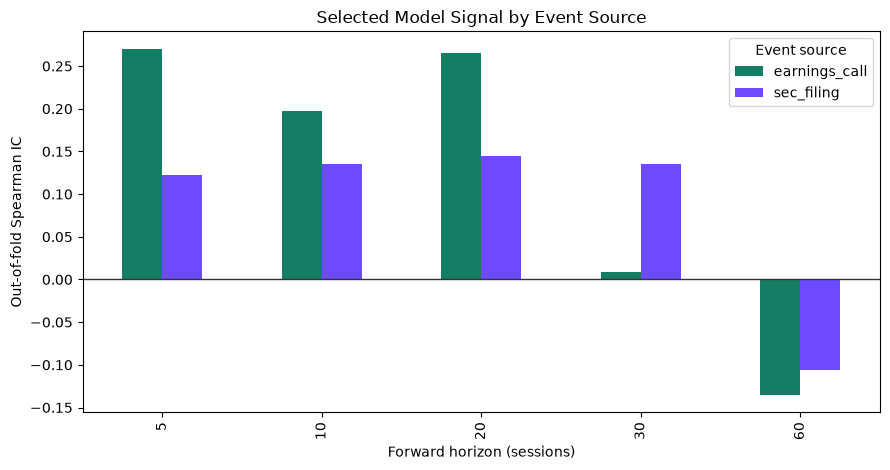

In [6]:
source_pivot = selected_sources.pivot(
    index='horizon',
    columns='event_source',
    values='spearman_ic',
)
ax = source_pivot.plot.bar(
    figsize=(9, 4.8),
    color=['#147d64', '#6d4aff'],
)
ax.axhline(0, color='#333333', linewidth=1)
ax.set_ylabel('Out-of-fold Spearman IC')
ax.set_xlabel('Forward horizon (sessions)')
ax.set_title('Selected Model Signal by Event Source')
ax.legend(title='Event source')
plt.tight_layout()

## Ten-Session Fold Evidence

In [7]:
candidate_10d = study.benchmarks[10].selection['selected_model']
fold_detail = study.benchmarks[10].fold_metrics.loc[
    study.benchmarks[10].fold_metrics.model.isin([
        candidate_10d,
        'historical_mean',
    ]),
    ['fold', 'model', 'rows', 'mae', 'directional_accuracy', 'spearman_ic'],
]
fold_detail.style.format({
    'mae': '{:.4f}',
    'directional_accuracy': '{:.1%}',
    'spearman_ic': '{:.3f}',
})

,fold,model,rows,mae,directional_accuracy,spearman_ic
1,fold_01,historical_mean,78,0.0264,46.2%,nan
3,fold_01,elasticnet_a01_l50,78,0.0258,52.6%,0.116
8,fold_02,historical_mean,80,0.0317,55.0%,nan
10,fold_02,elasticnet_a01_l50,80,0.0322,56.2%,0.017
15,fold_03,historical_mean,79,0.0328,40.5%,nan
17,fold_03,elasticnet_a01_l50,79,0.0325,48.1%,0.074
22,fold_04,historical_mean,77,0.0480,59.7%,nan
24,fold_04,elasticnet_a01_l50,77,0.0469,75.3%,0.427


## Research Decision

The selected target remains research-only. A future holdout and transaction-cost-aware strategy test are required before any registry promotion.

In [8]:
pd.Series(study.selection, name='value').to_frame()

,value
status,fresh_holdout_candidate
selected_horizon,10
selected_model,elasticnet_a01_l50
selection_rule,"Among eligible horizons, maximize relative MAE..."
relative_mae_improvement,0.01169
production_eligible,False
reason,Multiple horizons were explored on historical ...
